# 01 · Exploratory data analysis

**Automated Robson Ten-Group Classification and Cesarean Readiness System: ML workstream**

This notebook looks at the data only: what the UR-CMHS export (5,520 deliveries at four Kigali-area
hospitals) contains, how it is mapped and classified, what the outcome and the predictors look like, and
which variables are kept as model inputs. Training and evaluation are in the next notebooks.

| Notebook | Content |
|---|---|
| **01 · EDA** (this one) | Data inventory, data quality, Robson classification, outcome and predictors, leakage audit, populations |
| 02 · Model training | Features, model architectures, training, hyperparameter tuning, experiment tracking, metrics, confusion matrices, model selection |
| 03 · Model evaluation | Interpretation of the selected model, robustness, deployment, complete-case analysis, summary |
| 04 · Audit and research questions | Robson audit table, case-mix (RQ1), missing data (RQ2) |

**Data protection.** Only aggregates are shown: no record, identifier or individual value. Counts of 1-4
are shown as `<5`, and cells hidden to protect another cell as `*`. The logic lives in the tested package
`src/robson_ml`; this notebook calls it and displays the results.

In [1]:
from robson_ml import notebook

nb = notebook.setup()  # synthetic data unless ROBSON_NOTEBOOK_MODE=real
show = notebook.show

data: real


In [2]:
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from robson_ml import eda, figures
from robson_ml.feature_sets import GROUP_ORDER, build_model_data, feature_spec
from robson_ml.features import build_raw_features, check_coverage, load_feature_registry
from robson_ml.ingest import inventory, read_workbook, select_sheet
from robson_ml.mapping import load_mapping
from robson_ml.populations import audit_population, prediction_population
from robson_ml.privacy import SECONDARY, fmt_count, suppress_table
from robson_ml.profile import published_profile, released_quantiles, status_tables
from robson_ml.robson_run import handcheck_sample, validate_classification
from robson_ml.schema import validate_canonical

%matplotlib inline

# Everything below is held in memory and never displayed row-wise.
mapping = load_mapping(nb.at(nb.cfg.mapping_path))
sheets = read_workbook(nb.raw_path)
raw = select_sheet(sheets, mapping.sheet).reset_index(drop=True)
canonical = pd.read_parquet(nb.processed / "canonical.parquet")
classified = pd.read_parquet(nb.classified_path)
registry = load_feature_registry(nb.at(nb.cfg.features_path))
raw_features, _ = build_raw_features(raw, registry)
audit, audit_log = audit_population(classified)
data = build_model_data(classified, registry, raw_features, "P_pred")
notebook.environment()

,value
item,
executed at,2026-10-08 23:31
python,3.11.0
numpy,2.4.6
pandas,2.3.3
scikit-learn,1.9.1
xgboost,3.2.0
shap,0.51.0
mlflow,3.16.1
optuna,5.0.0


## 1. Data inventory

The sheets of the raw export, their size and the kind of each column (inferred from its values). Only
column names and counts are shown, never cell values.

In [3]:
inv = inventory(sheets)
sheet_rows = []
for i, sheet in enumerate(inv["sheets"], start=1):
    kinds = pd.Series([c["kind"] for c in sheet["columns"]]).value_counts()
    sheet_rows.append(
        {
            "sheet": f"sheet {i}",
            "rows": fmt_count(sheet["n_rows"]),
            "columns": sheet["n_cols"],
            "form versions": len(sheet.get("versions", {})),
            **{f"{kind} columns": int(n) for kind, n in kinds.items()},
        }
    )
display(pd.DataFrame(sheet_rows).fillna(0))

main = next(s for s in inv["sheets"] if s["n_rows"] == len(raw) and s["n_cols"] == raw.shape[1])
columns = pd.DataFrame(main["columns"])
columns["pct_complete"] = 100.0 * columns["n_nonnull"] / max(main["n_rows"], 1)
bands = pd.cut(
    columns["pct_complete"],
    bins=[-0.1, 0, 10, 50, 90, 99.9, 100],
    labels=["empty", "(0, 10]", "(10, 50]", "(50, 90]", "(90, 100)", "complete"],
)
display(pd.crosstab(bands, columns["kind"]).rename_axis(index="% complete", columns="kind"))
print(f"empty columns: {len(columns[columns['kind'] == 'empty'])}")

,sheet,rows,columns,form versions,categorical columns,empty columns,numeric columns,text columns,datetime columns
0,sheet 1,5520,160,0,82,36,33,8,1


kind,categorical,datetime,empty,numeric,text
% complete,,,,,
empty,0,0,36,0,0
"(0, 10]",6,0,0,11,1
"(10, 50]",8,0,0,4,2
"(50, 90]",4,0,0,2,1
"(90, 100)",0,0,0,2,0
complete,64,1,0,14,4


empty columns: 36


## 2. Mapping and data quality

`configs/mapping_ur_cmhs.yaml` maps raw columns to the canonical admission schema; ambiguous mappings are
flagged for review, never guessed. For each field, the raw non-missing values split into *mapped*,
*explicit missing* (a recorded "unknown"), *unparsed*, *out of range* and *incomplete*.

In [4]:
report = json.loads((nb.interim / "mapping_report.json").read_text(encoding="utf-8"))
parts = ["n_mapped", "n_explicit_missing", "n_unparsed", "n_out_of_range", "n_incomplete"]
fields = pd.DataFrame(report["fields"])
fields["unmapped levels"] = fields["unmapped_levels"].map(len)
mapping_table = eda.suppress_partition(
    fields[["canonical", "kind", "status", *parts, "unmapped levels"]], parts
)
display(mapping_table.set_index("canonical"))
print(f"fields flagged for review: {report['review_fields']}")
try:
    validate_canonical(canonical)
    print("canonical schema: valid (types, levels and plausible ranges)")
except Exception as error:
    print(f"canonical schema: INVALID ({type(error).__name__}; see the CLI in a private session)")

,kind,status,n_mapped,n_explicit_missing,n_unparsed,n_out_of_range,n_incomplete,unmapped levels
canonical,,,,,,,,
admission_id,row_key,confirmed,5520,0,0,0,0,0
mother_key,hash_key,confirmed,5520,0,0,0,0,0
facility_id,text,confirmed,5520,0,0,0,0,0
delivery_date,datetime,confirmed,5520,0,0,0,0,0
parity,integer_sum,review,5517,0,<5,0,<5,0
previous_cs_count,category,confirmed,*,0,<5,0,0,1
fetal_presentation,category,review,5520,0,0,0,0,0
plurality,category,review,5520,0,0,0,0,0
gestational_age_weeks,gestational_age,confirmed,3597,0,34,16,0,0


fields flagged for review: ['parity', 'fetal_presentation', 'plurality', 'ga_band_lower', 'ga_band_upper', 'onset_of_labour', 'prelabour_cs_type', 'anc_contacts']


canonical schema: valid (types, levels and plausible ranges)


## 3. Robson classification

The `robson_engine` package (shared with the application) classifies every record from the six Robson
inputs. A record is **resolved** when exactly one group fits, **partial** when several remain (e.g.
presentation recorded only as "non-cephalic"), and **conflict** when none does.

,n,pct
status,,
resolved,5213,94.4
partial,307,5.6
conflict,0,0.0


records: 5520; records with a coarse input: 2019; counts reconcile: True; hand-check sample (reviewed by hand, never shown): 153 records


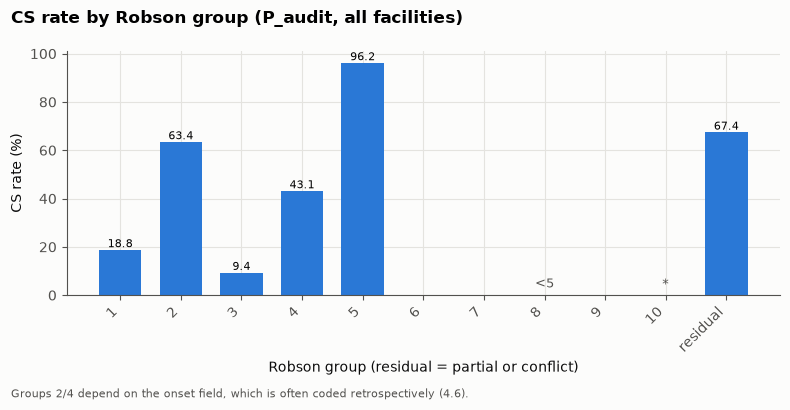

In [5]:
status, resolving, report_table = status_tables(classified)
display(status.set_index("status"))
check = validate_classification(classified)
print(
    f"records: {fmt_count(check.n_total)}; records with a coarse input: "
    f"{fmt_count(check.n_coarse_inputs)}; counts reconcile: {check.reconciles}; "
    f"hand-check sample (reviewed by hand, never shown): "
    f"{fmt_count(len(handcheck_sample(classified, nb.seed)))} records"
)
overall = report_table[report_table["facility"] == "ALL"].set_index("row")
show(
    figures.bar_chart(
        overall.index.tolist(),
        [v if isinstance(v, str) else 100 * float(v) for v in overall["cs_rate"]],
        "CS rate by Robson group (P_audit, all facilities)",
        "Robson group (residual = partial or conflict)",
        "CS rate (%)",
        note="Groups 2/4 depend on the onset field, which is often coded retrospectively (4.6).",
    )
)

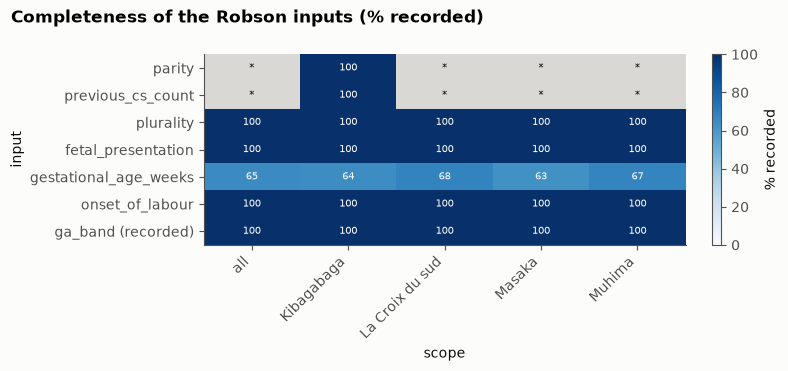

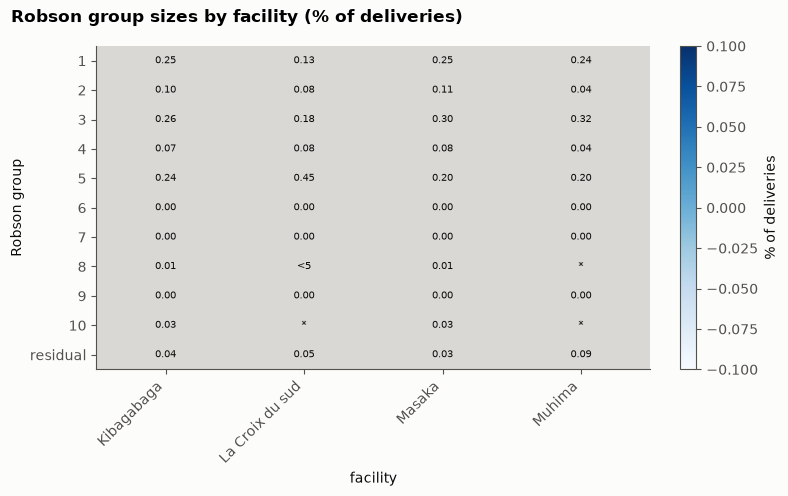

In [6]:
# Completeness of the six inputs and group sizes, overall and per facility.
profile_table, canonical_counts = published_profile(raw, classified, mapping)
show(
    figures.heatmap(
        canonical_counts.completeness.set_index("input"),
        "Completeness of the Robson inputs (% recorded)",
        "scope",
        "input",
        "% recorded",
        vmin=0,
        vmax=100,
    )
)
by_facility = report_table[report_table["facility"] != "ALL"]
size_matrix = by_facility.pivot(index="row", columns="facility", values="pct_of_deliveries")
size_matrix = size_matrix.reindex(overall.index).map(
    lambda v: v if isinstance(v, str) else 100 * float(v)
)
show(
    figures.heatmap(
        size_matrix,
        "Robson group sizes by facility (% of deliveries)",
        "facility",
        "Robson group",
        "% of deliveries",
        fmt="{:.1f}",
    )
)

## 4. Exploratory data analysis

Outcome rates are described on **P_audit** (every record with a known mode of delivery); predictors on
**P_pred**, the population the model is trained on (section 6).

### 4.1 Outcome: CS rate by facility and over time

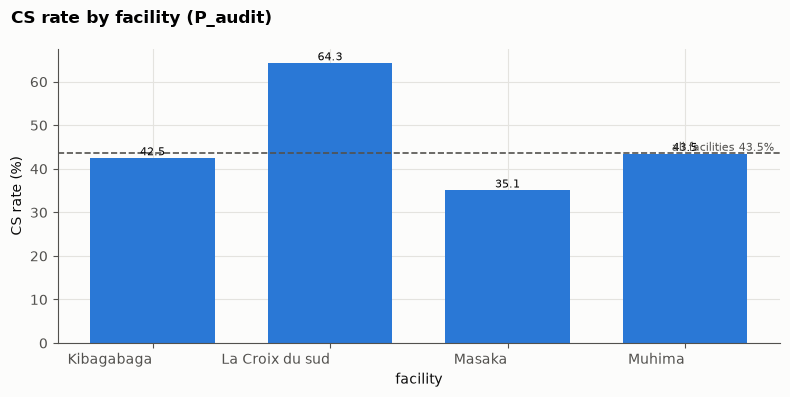

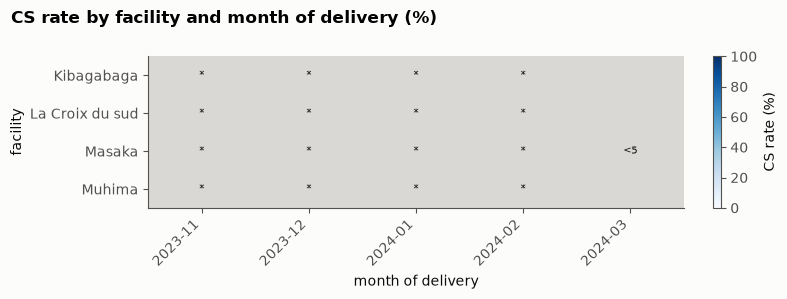

In [7]:
rates = eda.rate_by(audit, "facility_id")
overall_rate = 100.0 * float(audit["cs"].mean())
show(
    figures.bar_chart(
        rates["facility_id"].tolist(),
        rates["rate_pct"].tolist(),
        "CS rate by facility (P_audit)",
        "facility",
        "CS rate (%)",
        reference=overall_rate,
        reference_label=f"all facilities {overall_rate:.1f}%",
    )
)
audit_month = audit.assign(month=audit["delivery_date"].dt.to_period("M").astype(str))
cross = eda.rate_by(audit_month, ["facility_id", "month"])
show(
    figures.heatmap(
        cross.pivot(index="facility_id", columns="month", values="rate_pct"),
        "CS rate by facility and month of delivery (%)",
        "month of delivery",
        "facility",
        "CS rate (%)",
        vmin=0,
        vmax=100,
    )
)

### 4.2 Numeric predictors

Released quantiles of each numeric input, and the distributions of the key ones by mode of delivery (each
group as a percentage of its own total, so the shapes compare).

,% missing,p5,p25,p50,p75,p95
numeric feature (P_pred),,,,,,
gestational_age_weeks,34.0,36.0,38.571429,39.285714,40.0,41.285714
ga_band_lower,0.0,35.0,38.0,38.0,38.0,40.142857
ga_band_upper,0.0,37.857143,40.857143,40.857143,40.857143,45.0
parity,<5,0.0,0.0,1.0,2.0,4.0
previous_cs_count,<5,0.0,0.0,0.0,0.0,1.0
plurality,0.0,1.0,1.0,1.0,1.0,1.0
maternal_age,<5,18.1,23.0,28.0,33.0,40.0
height_cm,*,154.0,159.0,162.0,165.0,168.0
weight_kg,0.0,55.0,60.0,66.0,72.0,87.0


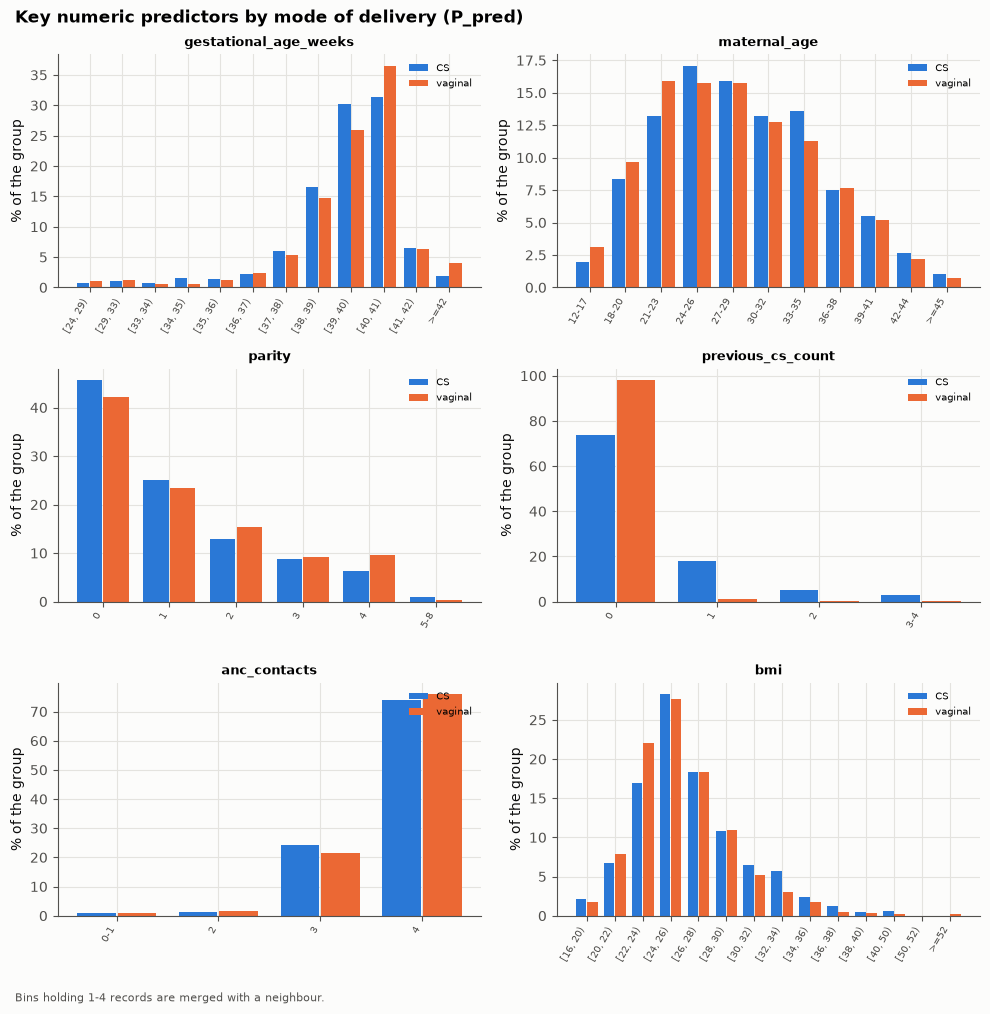

In [8]:
fs4 = feature_spec(data, "FS4")
x4 = data.x[list(fs4.columns)]
outcome = pd.Series(np.where(data.y == 1, "CS", "vaginal"), index=x4.index)
missingness = eda.missingness_matrix(x4, list(fs4.columns), data.meta["facility_id"])
summary = pd.DataFrame(
    {
        column: {
            "% missing": missingness.loc[column, "all"],
            **released_quantiles(x4[column].dropna().astype(float)),
        }
        for column in fs4.numeric
    }
).T
display(summary.rename_axis("numeric feature (P_pred)").round(2))

KEY_NUMERIC = (
    "gestational_age_weeks", "maternal_age", "parity", "previous_cs_count", "anc_contacts", "bmi"
)
histograms = {
    column: table
    for column in KEY_NUMERIC
    if column in x4.columns
    and not (table := eda.binned_hist_counts(x4[column], by=outcome, name=column)).empty
}
show(figures.histogram_grid(histograms, ["CS", "vaginal"], "Key numeric predictors by mode of delivery (P_pred)"))

### 4.3 Categorical predictors

Level counts and CS rates (rare levels pooled). The onset-free Robson group, the B1 baseline's only input,
is drawn below.

n n_outcome  \
feature               level                                               
fetal_presentation    cephalic                           4141      1052   
                      non_cephalic                        124       113   
robson_group_no_onset 10                                  214        50   
                      1_2                                1631       445   
                      3_4                                1851       252   
                      5                                   304         *   
                      8                                    15        <5   
                      partial                             250       151   
education_level       (rare)                               <5        <5   
                      Complete Primary school             749       242   
                      Completed secondary school         1025       234   
                      Did not complete primary school     979       272   
                      Did not complete secondary school  1152       274   
                      Did not go to school                  *         *   
                      University education or more        268        98   
residency             Rural                              1079       320   
                      Urban                              3186       845   
insurance_type        Mutuel                             3783       997   
                      None                                 48        18   
                      Others                              195        66   
                      RSSB                                239        84   
marital_status        Cohabitant                          488         *   
                      Divorced                              5        <5   
                      Married                            2354       673   
                      Never Married                      1418       338   
occupation            Full Time Job                       572       218   
                      N/A                                   8         0   
                      Not Working                        1475       318   
                      Part Time Job                      2210       629   
living_children_band  (missing)                          1623       483   
                      0                                    12        <5   
                      4 or more                           629         *   
                      Less than 4                        2001       517   
previous_stillbirth   No                                 4241      1156   
                      Yes                                  24         9   
preeclampsia_recorded (missing)                            <5        <5   
                      no                                 4220      1138   
                      yes                                   *         *   
hiv_positive          (missing)                            <5        <5   
                      No                                 4204      1151   
                      Yes                                   *         *   
ivf                   No                                 4260         *   
                      Yes                                   5        <5   
antenatal_admission   No                                 4220      1146   
                      Yes                                  45        19   
gdm_recorded          (rare)                               <5        <5   
                      no                                    *         *   
malaria_in_pregnancy  No                                 4253      1159   
                      Yes                                  12         6   
gu_infection          No                                 4234      1151   
                      Yes                                  31        14   

                                                        rate_pct  
feature          

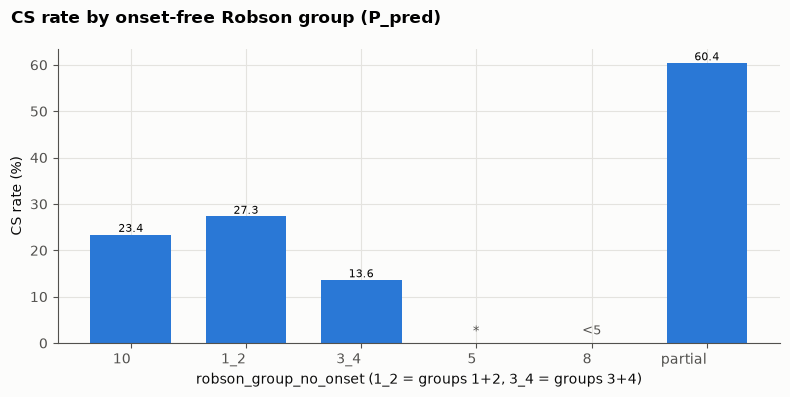

In [9]:
categorical_tables = []
for column in fs4.categorical:
    table = eda.level_rates(x4[column], pd.Series(data.y, index=x4.index))
    table.insert(0, "feature", column)
    categorical_tables.append(table)
categorical_summary = pd.concat(categorical_tables, ignore_index=True)
display(categorical_summary.set_index(["feature", "level"]))
robson_rates = categorical_summary[categorical_summary["feature"] == "robson_group_no_onset"]
show(
    figures.bar_chart(
        robson_rates["level"].tolist(),
        robson_rates["rate_pct"].tolist(),
        "CS rate by onset-free Robson group (P_pred)",
        "robson_group_no_onset (1_2 = groups 1+2, 3_4 = groups 3+4)",
        "CS rate (%)",
    )
)

### 4.4 Missing values and correlations

Missingness by feature and facility, and the Spearman correlation of the numeric features (a pair needs
at least `eda.MIN_CORRELATION_N` complete rows to be shown).

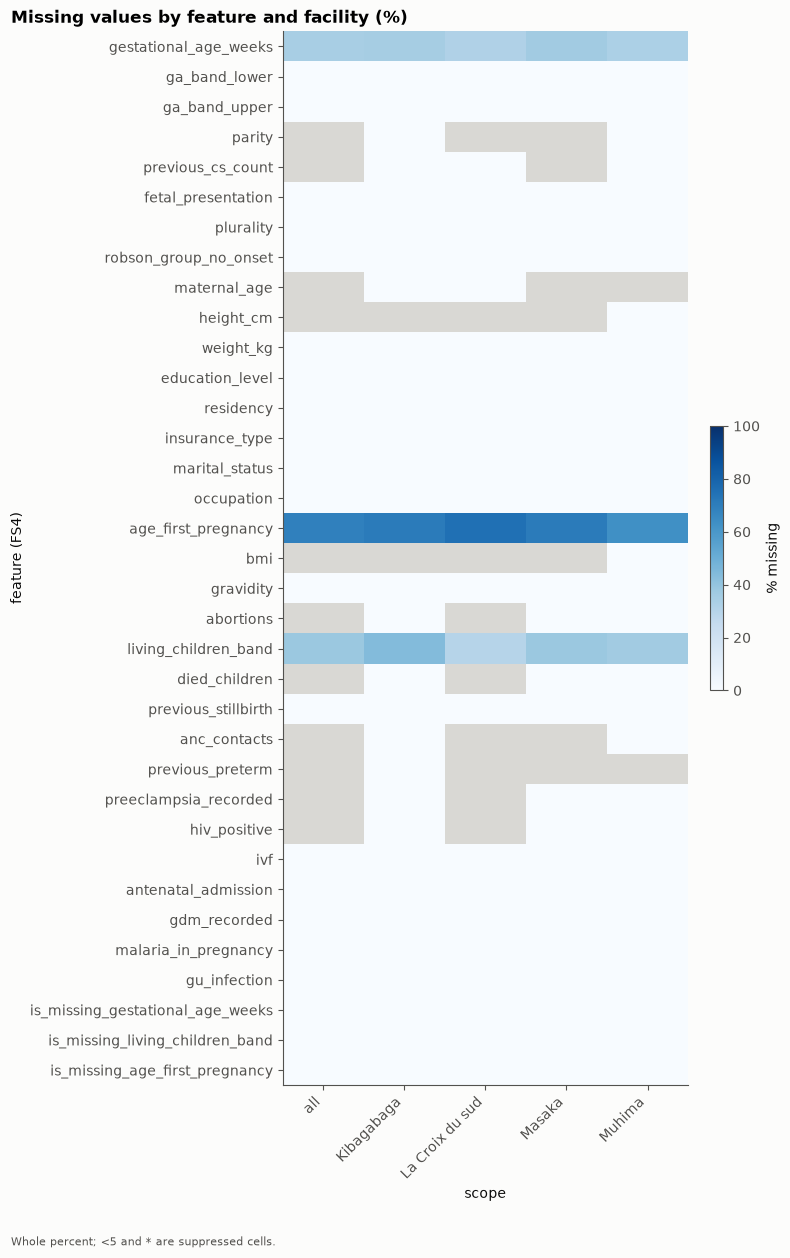

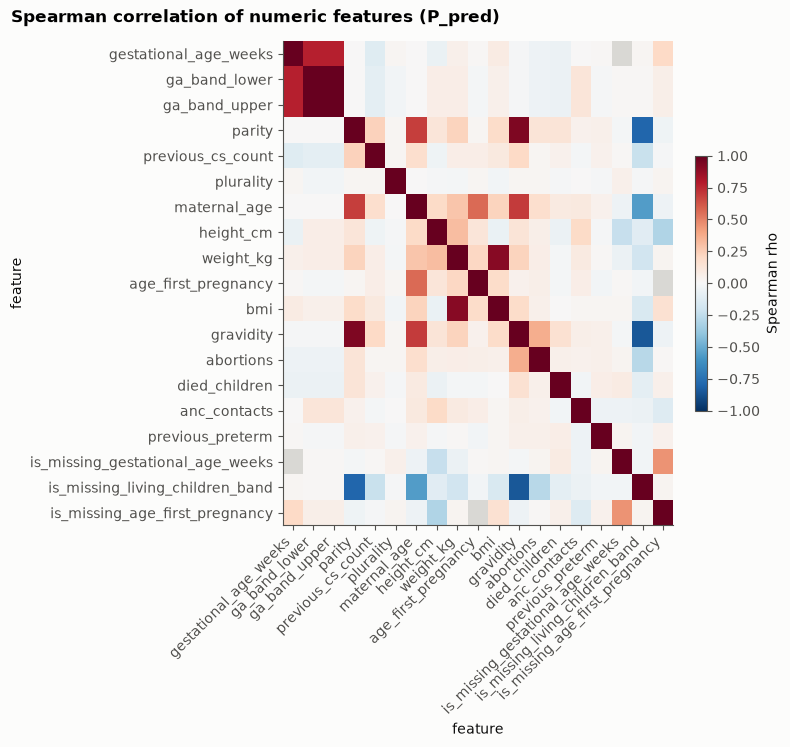

In [10]:
show(
    figures.heatmap(
        missingness,
        "Missing values by feature and facility (%)",
        "scope",
        "feature (FS4)",
        "% missing",
        vmin=0,
        vmax=100,
        note="Whole percent; <5 and * are suppressed cells.",
    )
)
show(
    figures.heatmap(
        eda.correlation_matrix(x4, list(fs4.numeric)).round(2),
        "Spearman correlation of numeric features (P_pred)",
        "feature",
        "feature",
        "Spearman rho",
        cmap=figures.DIVERGING,
        vmin=-1,
        vmax=1,
        fmt="{:.1f}",
    )
)

### 4.5 Univariate association with CS

The leave-one-hospital-out AUC of each raw column on its own (from the leakage screen); values above 0.85
are flagged for review (section 5).

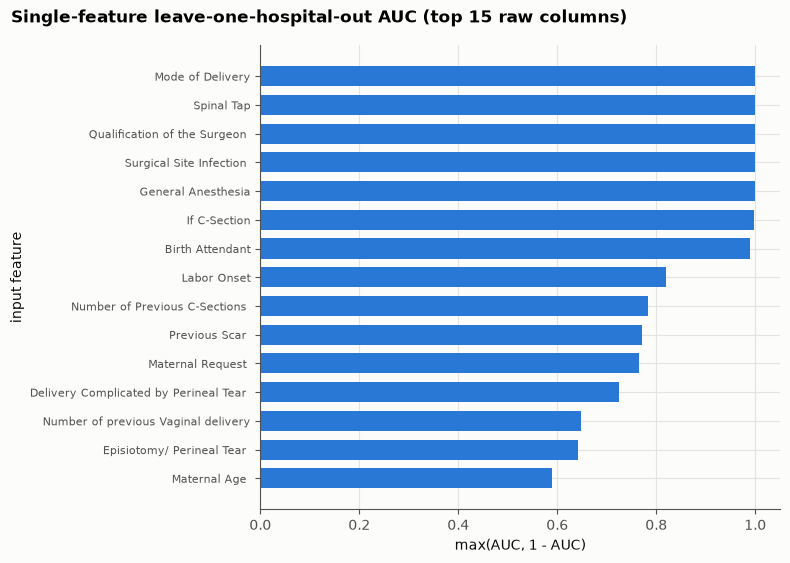

In [11]:
screens = pd.read_csv(nb.reports / "leakage" / "leakage_screens.csv")
screens["loho_auc_strength"] = np.maximum(screens["loho_auc"], 1 - screens["loho_auc"])
show(
    figures.importance_bars(
        screens.sort_values("loho_auc_strength", ascending=False).head(15).set_index("variable"),
        "loho_auc_strength",
        "Single-feature leave-one-hospital-out AUC (top 15 raw columns)",
        "max(AUC, 1 - AUC)",
    )
)

### 4.6 Data-quality findings

**Parity.** In the register, "Parity" counts the current birth, so canonical parity is derived as *previous
vaginal deliveries + previous CS* (top-coded at 4).

**Onset coded retrospectively.** If onset recorded what was known at admission, the share of CS coded
"pre-labour CS" would be stable and well below 100%. A share near 100% means that "Planned C-section"
onset often just means "had a CS". This is why onset is excluded from every model and from the
definition of P_pred.

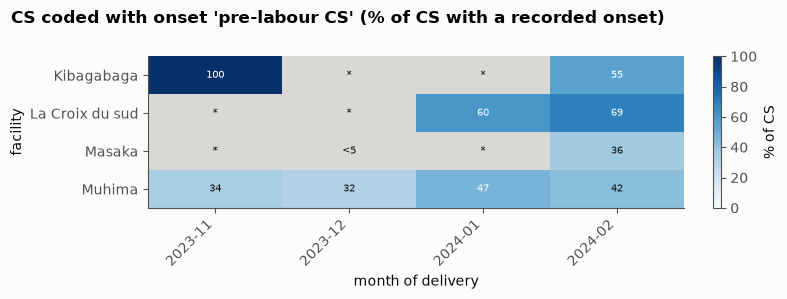

,emergency CS,coded pre-labour onset,%
facility_id,,,
Kibagabaga,237,168,70.9
La Croix du sud,144,9,6.2
Masaka,322,211,65.5
Muhima,451,31,6.9


In [12]:
onset_share = eda.prelabour_onset_share(audit)
show(
    figures.heatmap(
        onset_share.pivot(index="facility_id", columns="period", values="rate_pct"),
        "CS coded with onset 'pre-labour CS' (% of CS with a recorded onset)",
        "month of delivery",
        "facility",
        "% of CS",
        vmin=0,
        vmax=100,
    )
)
emergency = audit[(audit["cs"] == 1) & (audit["prelabour_cs_type"] == "emergency")]
emergency = emergency.assign(
    prelabour_onset=(emergency["onset_of_labour"] == "prelabour_cs")
    .astype(float)
    .where(emergency["onset_of_labour"].notna())
)
eda.rate_by(emergency, "facility_id", "prelabour_onset").rename(
    columns={"n": "emergency CS", "n_outcome": "coded pre-labour onset", "rate_pct": "%"}
).set_index("facility_id")

## 5. Leakage audit and feature registry

Automatic screens only **flag** variables for human review: a single-feature leave-one-hospital-out AUC
above 0.85, a post-admission or outcome-side name (indication, theatre, apgar, ...), or a variable recorded
mostly when `cs = 1`. Every exclusion in `configs/features_v1.yaml` was approved by hand before any model
was trained, and model code reads only `status: include`.

In [13]:
status_by_raw = {col: (e.name, e.status) for e in registry.entries for col in e.raw_name}
flagged = screens[screens["flagged"]].copy()
flagged["registry entry"] = flagged["variable"].map(lambda c: status_by_raw.get(c, ("-", "-"))[0])
flagged["registry status"] = flagged["variable"].map(lambda c: status_by_raw.get(c, ("-", "-"))[1])
print(f"screened raw columns: {len(screens)}; flagged: {fmt_count(int(screens['flagged'].sum()))}")
display(
    flagged[
        ["variable", "loho_auc", "auc_flag", "name_flag", "completeness_flag", "registry entry", "registry status"]
    ].round(3)
)

included = pd.DataFrame(
    [{"group": e.group, "feature": e.name, "source": e.source} for e in registry.included()]
)
included["group"] = pd.Categorical(included["group"], categories=list(GROUP_ORDER), ordered=True)
missing_from_registry, not_in_export = check_coverage(registry, [str(c) for c in raw.columns])
print(
    f"registry: {len(registry.entries)} entries, {len(included)} included; raw columns missing "
    f"from the registry: {len(missing_from_registry)}"
)
included.sort_values(["group", "feature"]).set_index(["group", "feature"])

screened raw columns: 115; flagged: 54


,variable,loho_auc,auc_flag,name_flag,completeness_flag,registry entry,registry status
18,Number of Previous C-Sections,0.784,False,True,False,previous_cs_count,include
21,Duration of Labor,0.503,False,True,False,labour_duration,exclude
22,Birth Attendant,0.988,True,False,False,birth_attendant,exclude
23,Mode of Delivery,1.000,True,False,False,cs,exclude
24,If C-Section,0.997,True,True,True,prelabour_cs_type,exclude
25,Maternal Request,0.766,False,False,True,maternal_request,exclude
41,Time of Delivery,0.531,False,True,False,delivery_time,exclude
42,Twin baby,0.507,False,True,False,twin_baby,exclude
43,Birth Weight,0.502,False,True,False,birth_weight,exclude
44,Birth weight for twin baby,0.503,False,True,False,birth_weight_twin,exclude


registry: 165 entries, 34 included; raw columns missing from the registry: 0


source
group      feature                                    
G_robson   fetal_presentation                canonical
           gestational_age_band              canonical
           gestational_age_weeks             canonical
           parity                            canonical
           plurality                         canonical
           previous_cs_count                 canonical
           robson_group_no_onset               derived
G_maternal age_first_pregnancy                     raw
           bmi                                 derived
           education_level                         raw
           height_cm                         canonical
           insurance_type                          raw
           marital_status                          raw
           maternal_age                      canonical
           occupation                              raw
           residency                               raw
           weight_kg                         canonical
G_obs      abortions                               raw
           anc_contacts                      canonical
           antenatal_admission                     raw
           died_children                           raw
           gdm_recorded                      canonical
           gravidity                               raw
           gu_infection                            raw
           hiv_positive                            raw
           ivf                                     raw
           living_children_band                    raw
           malaria_in_pregnancy                    raw
           preeclampsia_recorded             canonical
           previous_preterm                        raw
           previous_stillbirth                     raw
G_missing  is_missing_age_first_pregnancy      derived
           is_missing_gestational_age_weeks    derived
           is_missing_living_children_band     derived

## 6. Populations

| Population | Definition |
|---|---|
| `P_audit` | Every record with a known mode of delivery. Used for the Robson tables and case mix. |
| `P_pred` | `P_audit` minus admissions with a **CS already planned at admission**. This mirrors deployment: a planned CS gets a Robson group but no readiness score. |

canonical records: 5520; P_audit: 5520, of which CS 2403


,n,n_cs
P_audit =,,
excluded: planned CS (elective type),1238,1238
"excluded: planned-CS onset, vaginal birth",17,0
P_pred,4265,1165


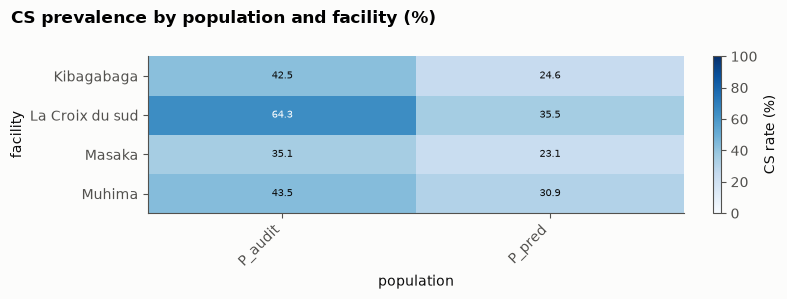

In [14]:
pred_frame, pred_logs = prediction_population(audit)
table = data.exclusion_table.set_index("category")
flow = pd.DataFrame(
    {
        "n": [int(table.loc[c, "n_excluded"]) for c in table.index[:2]] + [len(pred_frame)],
        "n_cs": [int(table.loc[c, "n_cs_excluded"]) for c in table.index[:2]]
        + [int(pred_frame["cs"].sum())],
    },
    index=[*(f"excluded: {c}" for c in table.index[:2]), "P_pred"],
)
print(
    f"canonical records: {fmt_count(len(classified))}; P_audit: {fmt_count(len(audit))}, "
    f"of which CS {fmt_count(int(audit['cs'].sum()))}"
)
display(suppress_table(flow, ["n", "n_cs"], complements={"n_cs": "n"}).rename_axis("P_audit ="))
prevalence = eda.nested_population_rates({"P_audit": audit, "P_pred": pred_frame})
show(
    figures.heatmap(
        prevalence.pivot(index="facility_id", columns="population", values="rate_pct"),
        "CS prevalence by population and facility (%)",
        "population",
        "facility",
        "CS rate (%)",
        vmin=0,
        vmax=100,
        fmt="{:.1f}",
    )
)

## Summary

* 94.4% of deliveries are classified into a single Robson group automatically; the rest stay partial
  because presentation or gestational age is recorded only coarsely. No record is contradictory.
* The onset-of-labour field is filled in after the fact at two hospitals, so it is never a model input and
  the Robson feature merges groups 1+2 and 3+4.
* `P_pred` (the training population) excludes admissions with a CS already planned at admission.

**Next:** [`02_model_training.ipynb`](02_model_training.ipynb) trains and compares the models.